In [7]:
# Improvements the training pipeline and more data augmentation

In [29]:
import torch
from torch import optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
import random
import datetime

from fifth_dataset import DunexDataset
from network import ResNetUNet
import torch
from visualize_dataset import plot_dataset_grid
from loss import calc_loss
import os
import gc

%load_ext autoreload
%autoreload 2

plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ResNetUNet(n_class=1)
# model = torch.compile(model)  # Add this after model definition
model = model.to(device)


In [31]:
sequential_transects = 3
samples_per_image = 1
ds = DunexDataset(['cvat_annotations/triplets_fully_labeled/annotations_poly_updated.xml', 
                   'cvat_annotations/additional_data/annotations_poly.xml'],
                  samples_per_image = samples_per_image,
                  use_missing_data=True)
# ds.p_augmentation=1
# ds.p_missing_data=1
train, val = torch.utils.data.random_split(ds, (80 * samples_per_image, 5 * samples_per_image))
batch_size = 32

# Should be deterministic, might need to change to add more workers 
batch_size=32
dataloaders = {
    'train': DataLoader(train, 
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=4,  # 4 seems to bottleneck
                        pin_memory=True,
                        persistent_workers=True),
    'val': DataLoader(val, 
                      batch_size=batch_size,
                      shuffle=True,
                      num_workers=4,
                      pin_memory=True,
                      persistent_workers=True)
} 


In [32]:
# plot_dataset_grid(dataloaders['val'].dataset, 256, indices=1*np.arange(0, 256))

In [33]:
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm import tqdm
import gc
import os
import signal
import datetime
from contextlib import contextmanager
import matplotlib.pyplot as plt
import numpy as np

def save_sample_visualizations(inputs, outputs, labels, epoch, filename='training_samples.png'):
    """Save a grid of sample inputs, outputs, and labels"""
    plt.clf()  # Clear the current figure
    
    # Select random indices for visualization
    batch_size = inputs.shape[0]
    indices = np.random.choice(batch_size, min(4, batch_size), replace=False)
    
    fig, axes = plt.subplots(4, len(indices), figsize=(16, 8))
    fig.suptitle(f'Training Samples - Epoch {epoch}')
    
    for idx, sample_idx in enumerate(indices):
        # Input
        axes[0, idx].imshow(inputs[sample_idx].cpu().detach().numpy().transpose(1, 2, 0))
        axes[0, idx].axis('off')
        axes[0, idx].set_title('Input')
        
        # Output
        axes[1, idx].imshow(outputs[sample_idx].cpu().detach().numpy().transpose(1, 2, 0))
        axes[1, idx].axis('off')
        axes[1, idx].set_title('Output')
        
        # Output
        axes[2, idx].imshow(outputs[sample_idx].cpu().detach().numpy().transpose(1, 2, 0) > 0.5)
        axes[2, idx].axis('off')
        axes[2, idx].set_title('Output')
        
        # Label/Ground Truth
        axes[3, idx].imshow(labels[sample_idx].cpu().detach().numpy().transpose(1, 2, 0))
        axes[3, idx].axis('off')
        axes[3, idx].set_title('Ground Truth')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close(fig)

@contextmanager
def dataloader_manager(dataloaders):
    """Context manager to properly handle dataloader cleanup"""
    try:
        yield dataloaders
    finally:
        # Ensure proper cleanup of workers
        for phase in dataloaders:
            if hasattr(dataloaders[phase], '_iterator'):
                iterator = dataloaders[phase]._iterator
                if iterator is not None:
                    iterator._shutdown_workers()

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))
    print("{}: {}".format(phase, ", ".join(outputs)))

def train_model(model, optimizer, scheduler, dataloaders, device, 
                start_epoch=0, num_epochs=200, gradient_clip_val=1.0):
    """Enhanced training loop with gradient clipping, loss monitoring, and detailed metrics tracking"""
    validation_metrics = defaultdict(list)
    train_metrics = defaultdict(list)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    last_checkpoint = None
    patience = 20
    patience_counter = 0
    moving_avg_loss = []
    
    with dataloader_manager(dataloaders):
        try:
            for epoch in range(start_epoch, num_epochs):
                since = time.time()
                
                for phase in ['train', 'val']:
                    metrics = defaultdict(float)
                    epoch_samples = 0
                    
                    if phase == 'train':
                        model.train()
                        lr = optimizer.param_groups[0]['lr']
                    else:
                        model.eval()
                        lr = 0.0
                    
                    with tqdm(dataloaders[phase], desc=f'epoch:{epoch} - {phase} - lr:{lr:.2e}') as pbar:
                        for batch_idx, (inputs, labels) in enumerate(pbar):
                            try:
                                inputs = inputs.to(device)
                                labels = labels.to(device)
                                
                                optimizer.zero_grad()
                                
                                with torch.set_grad_enabled(phase == 'train'):
                                    outputs = model(inputs)
                                    loss = calc_loss(outputs, labels, metrics, epoch, 
                                                   start_boundary_epoch=num_epochs//3)
                                    
                                    # Save visualizations for first batch of each epoch
                                    if batch_idx == 0 and phase == 'train':
                                        os.makedirs(f'./training/{datetime.date.today()}', exist_ok=True)
                                        save_sample_visualizations(
                                            inputs, outputs, labels, 
                                            epoch,
                                            filename=f'training/{datetime.date.today()}/training_progress_{epoch}.png'
                                        )
                                    
                                    if phase == 'train':
                                        loss.backward()
                                        # Clip gradients
                                        torch.nn.utils.clip_grad_norm_(
                                            model.parameters(), 
                                            gradient_clip_val
                                        )
                                        optimizer.step()
                                        scheduler.step()
                                
                                epoch_samples += inputs.size(0)
                                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
                                
                                # Monitor for explosion
                                if not torch.isfinite(loss):
                                    print(f"Loss exploded to {loss.item()} at epoch {epoch}")
                                    return model, moving_avg_loss, train_metrics, validation_metrics
                                
                            except Exception as e:
                                print(f"Error in batch: {e}")
                                continue
                    
                    # Update metrics and save checkpoints
                    if epoch_samples > 0:
                        # Update detailed metrics
                        if phase == 'train':
                            train_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                            train_metrics['focal'].append(metrics['focal']/epoch_samples)
                            train_metrics['dice'].append(metrics['dice']/epoch_samples)
                            train_metrics['disc'].append(metrics['disc']/epoch_samples)
                            train_metrics['loss'].append(loss.detach().cpu())
                            
                        if phase == 'val':
                            validation_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                            validation_metrics['focal'].append(metrics['focal']/epoch_samples)
                            validation_metrics['dice'].append(metrics['dice']/epoch_samples)
                            validation_metrics['disc'].append(metrics['disc']/epoch_samples)
                            validation_metrics['loss'].append(loss.detach().cpu())
                            
                        print_metrics(metrics, epoch_samples, phase)
                        epoch_loss = metrics['loss'] / epoch_samples
                        
                        if phase == 'val':
                            moving_avg_loss.append(epoch_loss)
                            
                            # Early stopping check
                            if epoch_loss < best_loss:
                                best_loss = epoch_loss
                                best_model_wts = copy.deepcopy(model.state_dict())
                                patience_counter = 0
                                
                                # Save checkpoint
                                if last_checkpoint:
                                    try:
                                        os.remove(last_checkpoint)
                                    except OSError:
                                        pass
                                last_checkpoint = f'checkpoint_epoch{epoch}_{datetime.date.today()}.pt'
                                torch.save({
                                    'epoch': epoch,
                                    'model_state_dict': model.state_dict(),
                                    'optimizer_state_dict': optimizer.state_dict(),
                                    'loss': best_loss,
                                }, last_checkpoint)
                            else:
                                patience_counter += 1
                                if patience_counter >= patience:
                                    print(f"Early stopping triggered at epoch {epoch}")
                                    model.load_state_dict(best_model_wts)
                                    return model, moving_avg_loss, train_metrics, validation_metrics
                
                # Memory cleanup
                gc.collect()
                torch.cuda.empty_cache() if torch.cuda.is_available() else None
                
        except KeyboardInterrupt:
            print("\nTraining interrupted. Saving checkpoint...")
            model.load_state_dict(best_model_wts)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
            }, f'interrupted_checkpoint_{datetime.date.today()}.pt')
            return model, moving_avg_loss, train_metrics, validation_metrics
            
    print('Best val loss: {:4f}'.format(best_loss))
    model.load_state_dict(best_model_wts)
    return model, moving_avg_loss, train_metrics, validation_metrics


In [34]:
from torch.optim.lr_scheduler import OneCycleLR

# Follow up training based on blow up

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
num_class = 1
model = ResNetUNet(num_class).to(device)

suggested_lr = 1e-03
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-2,
    weight_decay=1e-4)


epochs = 300
# optimizer = Adam(model.parameters(), lr=suggested_lr)

scheduler = OneCycleLR(
    optimizer_ft,
    max_lr=5e-3,
    epochs=epochs,
    steps_per_epoch=len(dataloaders['train']),
    pct_start=0.3,
    div_factor=25,
    final_div_factor=1e4,
    anneal_strategy='cos',
)

# torch.mps.caching_allocator_set_fraction(0.9)  # Set before training

model, loss_history, train_metrics, val_metrics = train_model(
    model, 
    optimizer_ft, 
    scheduler, 
    dataloaders,
    device,
    start_epoch=0, 
    num_epochs=epochs
)
torch.save(model.state_dict(), f'best_model_{datetime.date.today().strftime('%Y%m%d')}.pt')


epoch:0 - train - lr:2.00e-04: 100%|██████████| 3/3 [00:07<00:00,  2.56s/it, loss=0.3924]


train: focal: 0.041216, dice: 0.932091, loss: 0.397566, boundary: 0.000000, disc: 0.000000


epoch:0 - val - lr:0.00e+00: 100%|██████████| 1/1 [00:05<00:00,  5.84s/it, loss=0.3847]


val: focal: 0.025471, dice: 0.923620, loss: 0.384731, boundary: 0.000000, disc: 0.000000


epoch:1 - train - lr:2.01e-04: 100%|██████████| 3/3 [00:01<00:00,  1.70it/s, loss=0.3857]


...

val: focal: 0.175348, dice: 0.718012, loss: 0.424060, disc: 0.708874, boundary: 0.000000


epoch:46 - train - lr:2.70e-03:  33%|███▎      | 1/3 [00:00<00:01,  1.08it/s, loss=0.1808]



Training interrupted. Saving checkpoint...


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

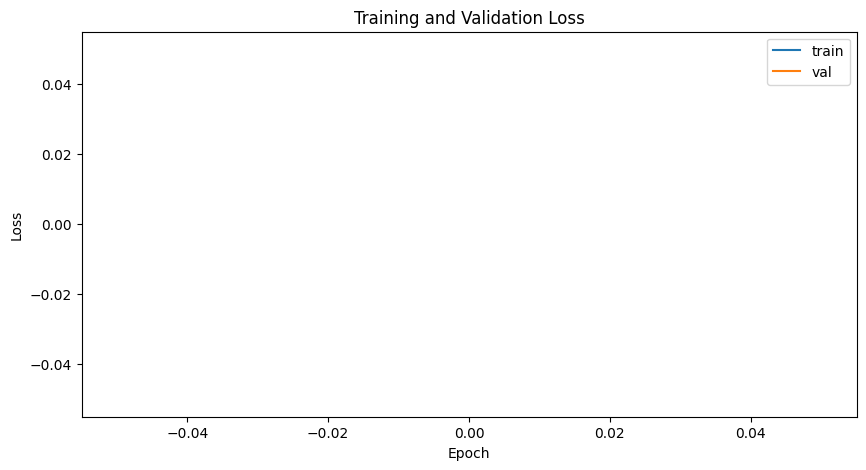

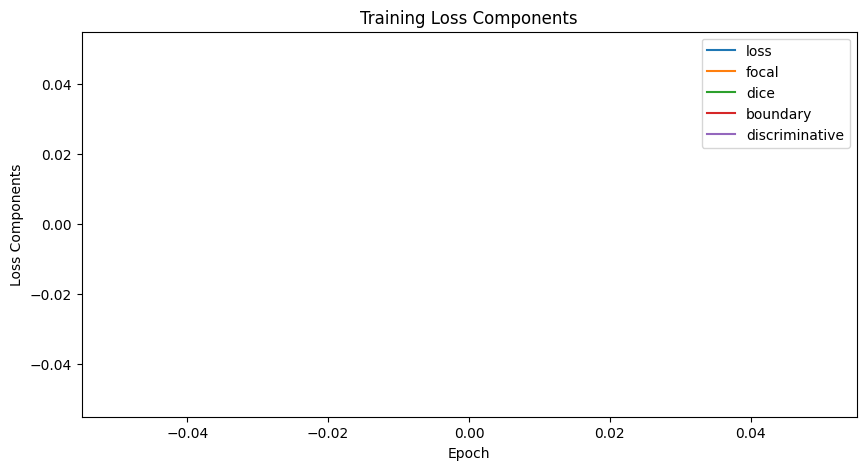

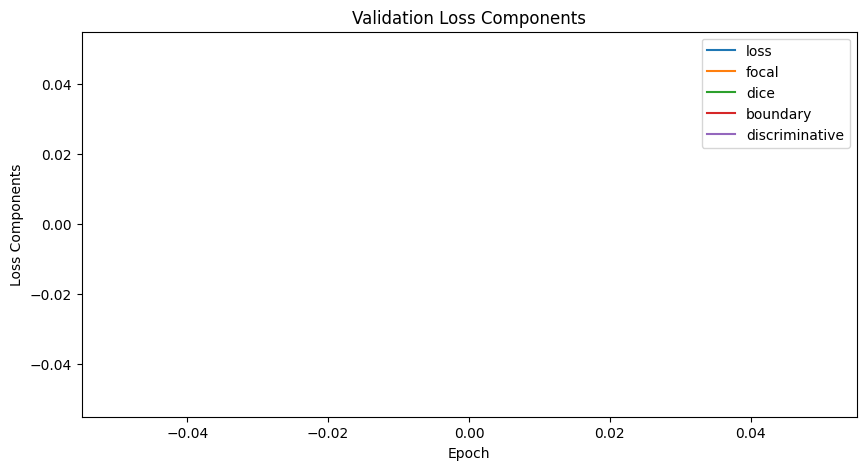

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='train')
plt.plot(val_metrics['loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='loss')
plt.plot(train_metrics['focal'], label='focal')
plt.plot(train_metrics['dice'], label='dice')
plt.plot(train_metrics['boundary_loss'], label='boundary')
plt.plot(train_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Training Loss Components')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(val_metrics['loss'], label='loss')
plt.plot(val_metrics['focal'], label='focal')
plt.plot(val_metrics['dice'], label='dice')
plt.plot(val_metrics['boundary_loss'], label='boundary')
plt.plot(val_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Validation Loss Components')
plt.legend()

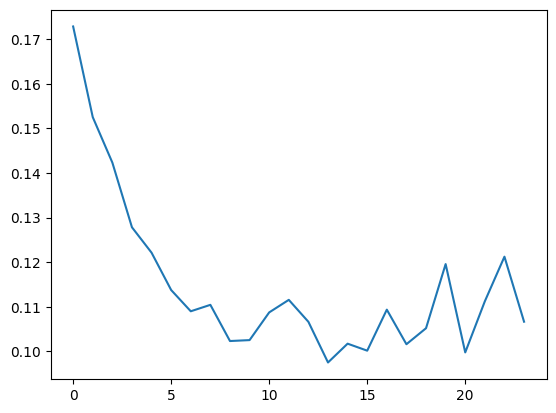

In [26]:
plt.plot(loss_history)

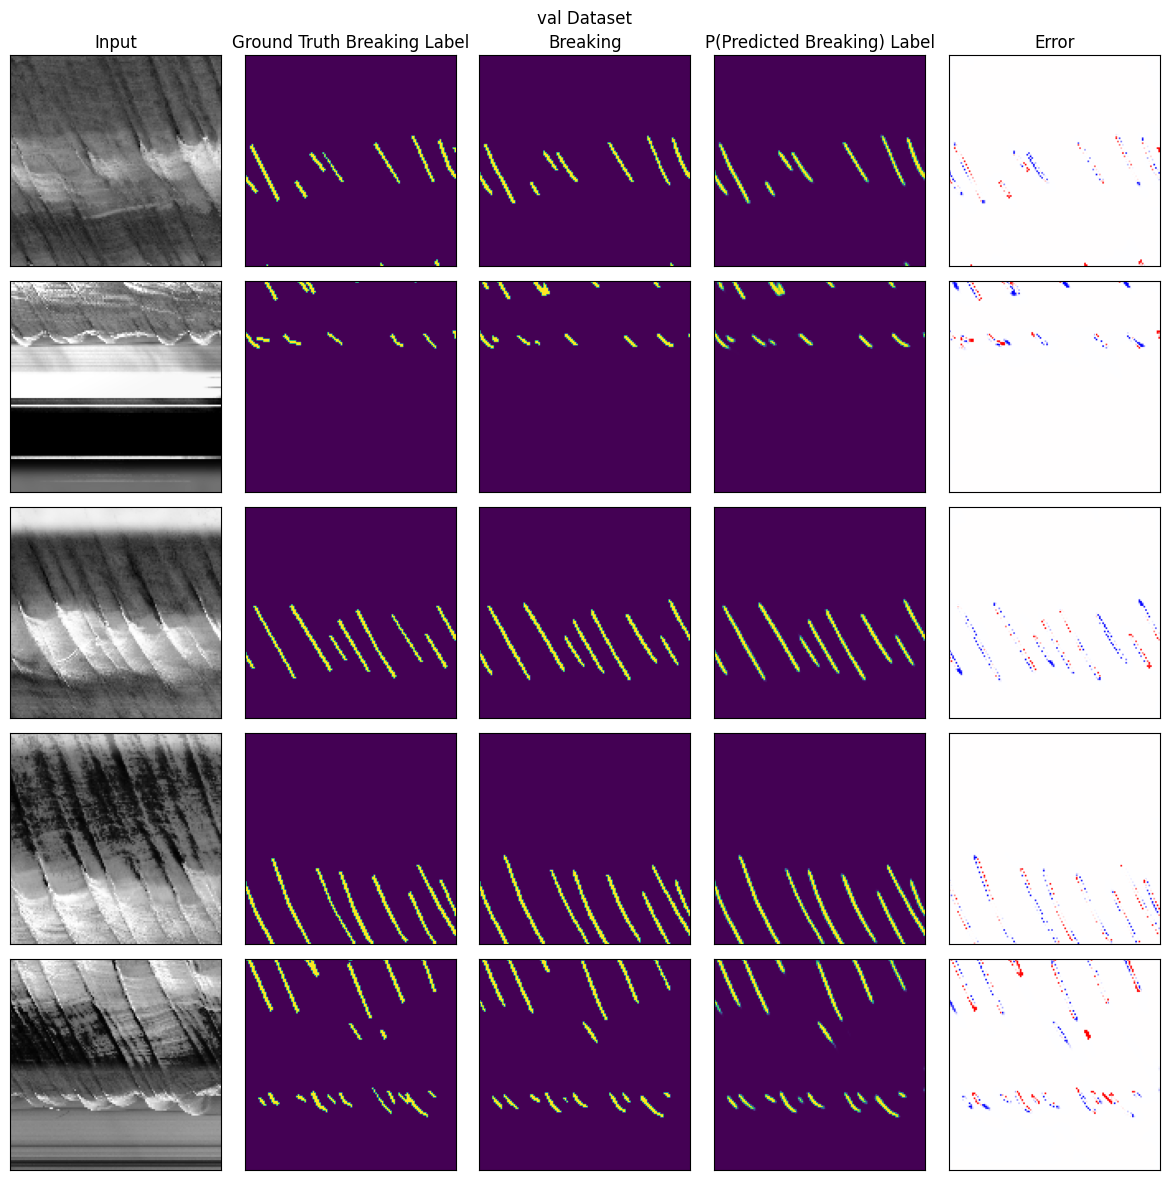

In [28]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='val'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis', vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')

fig.suptitle(f'{d} Dataset')
plt.tight_layout()
plt.show()
